In [35]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [36]:
# needed lybraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. How many total orders has UrbanCart received so far?

#### 1. How many total orders has UrbanCart received so far?

         city  total_orders  total_revenue
0  Chattogram            99         181812
1    Barishal            93         176536
2      Sylhet            93         174507
3     Cumilla            88         172860
4     Rangpur            71         124761
Index(['city', 'total_orders', 'total_revenue'], dtype='str')


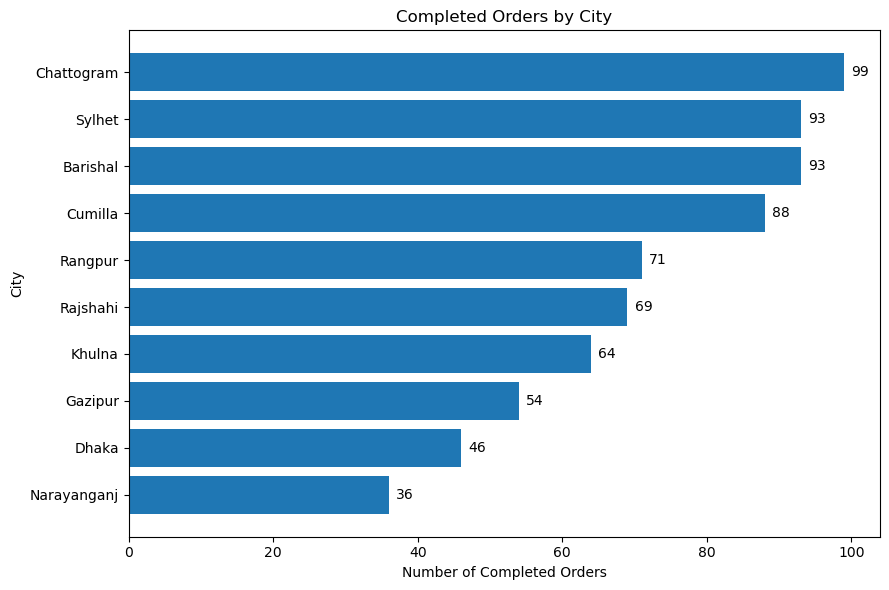

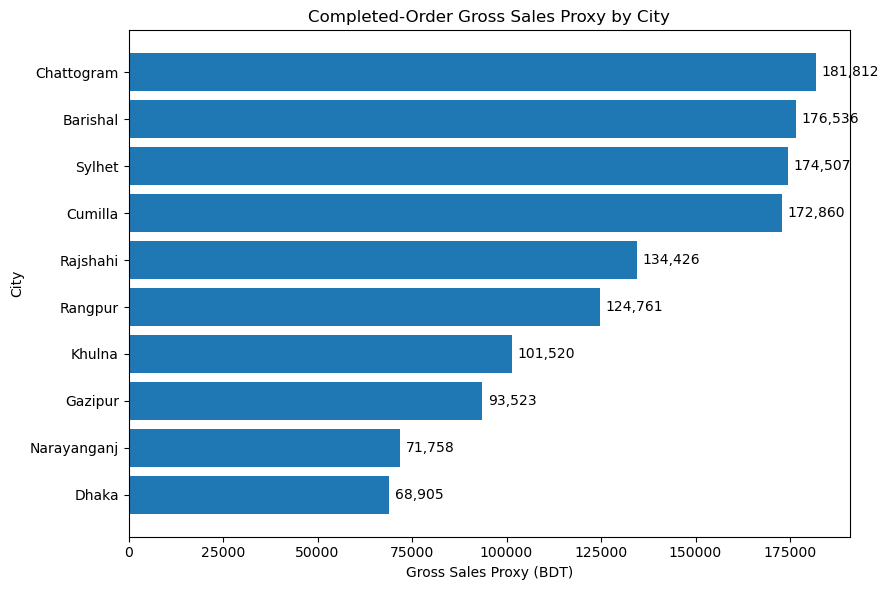

In [26]:

# -----------------------------
# 1. Load your exported SQL file
# -----------------------------
df = pd.read_csv("question 2.csv")

# Fix the typo in the column name
df = df.rename(columns={"total_oders": "total_orders"})

# Check the data
print(df.head())
print(df.columns)

# -----------------------------
# 2. Visualize orders by city
# -----------------------------
orders_df = df.sort_values("total_orders", ascending=True)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    orders_df["city"],
    orders_df["total_orders"]
)

plt.title("Completed Orders by City")
plt.xlabel("Number of Completed Orders")
plt.ylabel("City")

# Add values beside the bars
for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)}",
        va="center"
    )

plt.tight_layout()

# Save the chart
plt.savefig(
    "res_img/q2_completed_orders_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -----------------------------
# 3. Visualize gross sales proxy
# -----------------------------
revenue_df = df.sort_values("total_revenue", ascending=True)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    revenue_df["city"],
    revenue_df["total_revenue"]
)

plt.title("Completed-Order Gross Sales Proxy by City")
plt.xlabel("Gross Sales Proxy (BDT)")
plt.ylabel("City")

# Add values beside the bars
for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 1500,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center"
    )

plt.tight_layout()

# Save the chart
plt.savefig(
    "res_img/q2_completed_order_gross_sales_proxy_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 3. What percent of total customers uses gmail?

'\n# Save the chart as a high-quality image\nplt.savefig(\n    "res_img/q3_customer_distribution_by_email_provider.png",\n    dpi=300,\n    bbox_inches="tight"\n)\n\nplt.show()\n\n'

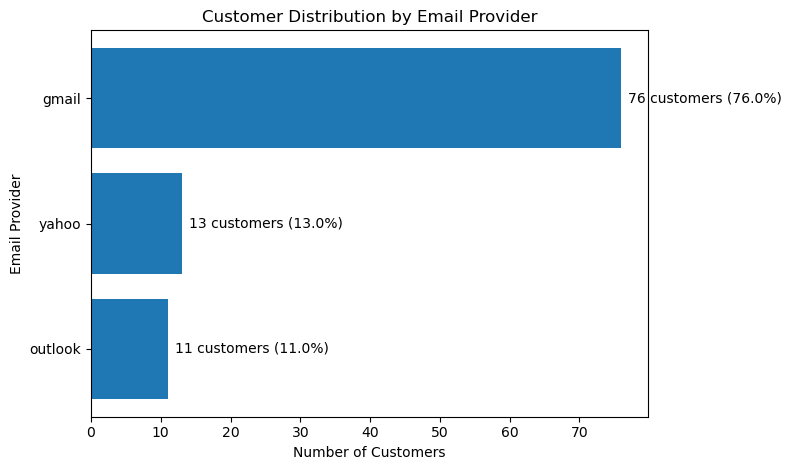

In [8]:
# Load your exported SQL result
df = pd.read_csv("question 3.csv")

# Sort the data so the largest bar appears at the top
plot_df = df.sort_values("total_customers", ascending=True)

# Create the horizontal bar chart
plt.figure(figsize=(8, 4.8))

bars = plt.barh(
    plot_df["email_provider"],
    plot_df["total_customers"]
)

plt.title("Customer Distribution by Email Provider")
plt.xlabel("Number of Customers")
plt.ylabel("Email Provider")

# Add customer count and percentage labels
for bar, percentage in zip(bars, plot_df["percentage"]):
    value = bar.get_width()

    plt.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)} customers ({percentage:.1f}%)",
        va="center"
    )

plt.tight_layout()

# Save the chart as a high-quality image
plt.savefig(
    "res_img/q3_customer_distribution_by_email_provider.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()




#### 4. What is the monthly trend of total orders over time?

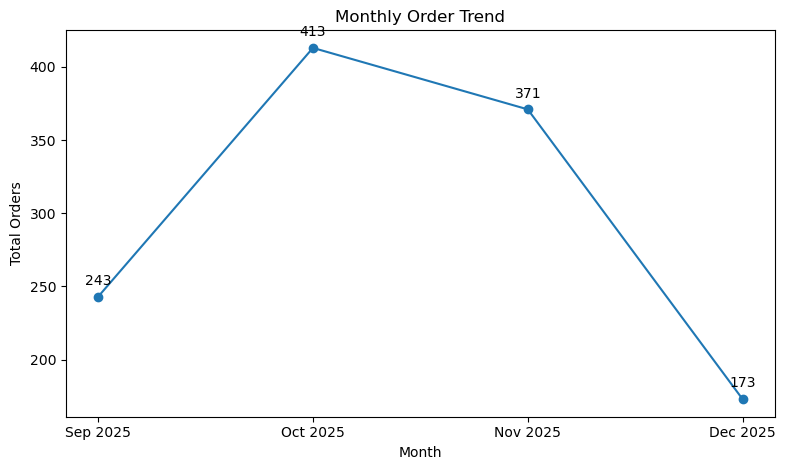

In [11]:


# Load the exported SQL result
df = pd.read_csv("question 4.csv")

# Convert the month column into a proper date format
df["order_month"] = pd.to_datetime(
    df["order_month"],
    format="%Y-%m"
)

# Sort the data chronologically
df = df.sort_values("order_month")

# Create readable labels
df["month_label"] = df["order_month"].dt.strftime("%b %Y")

# Create the line chart
plt.figure(figsize=(8, 4.8))

plt.plot(
    df["month_label"],
    df["total_orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")

# Add numbers above each point
for x, y in zip(df["month_label"], df["total_orders"]):
    plt.text(
        x,
        y + 8,
        f"{int(y)}",
        ha="center"
    )

plt.tight_layout()

# Save the chart
plt.savefig(
    "res_img/q4_monthly_order_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5. What is the Completed, Pending & Cancelled Rate?

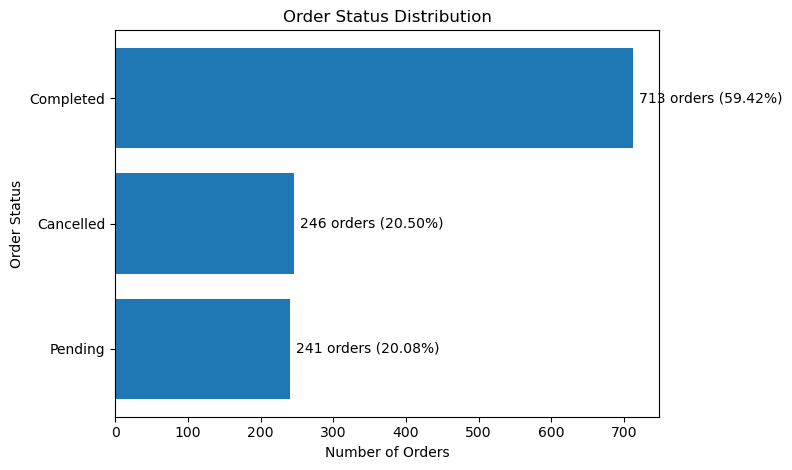

In [12]:
# Load the exported SQL result
df = pd.read_csv("question 5.csv")

# Sort so the largest bar appears at the top
plot_df = df.sort_values("total_orders", ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(8, 4.8))

bars = plt.barh(
    plot_df["status"],
    plot_df["total_orders"]
)

plt.title("Order Status Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")

# Add count and percentage labels
for bar, percentage in zip(bars, plot_df["rate_of_status"]):
    value = bar.get_width()

    plt.text(
        value + 8,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)} orders ({percentage:.2f}%)",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "res_img/q5_order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 6. What is the total revenue generated by UrbanCart?

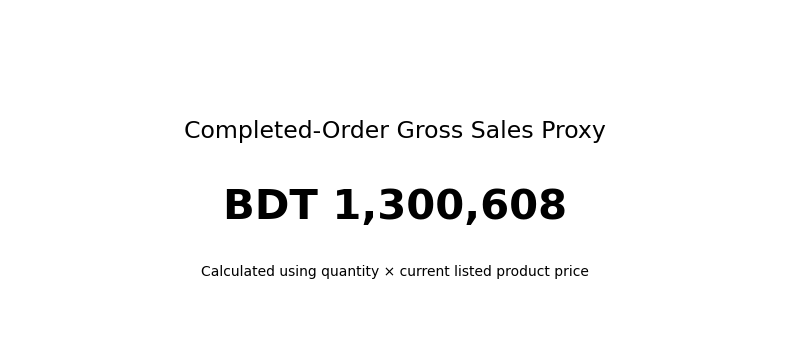

In [13]:
df = pd.read_csv("question 6.csv")

# Extract the value
gross_sales_proxy = df["sum"].iloc[0]

# Create a KPI-style visualization
plt.figure(figsize=(8, 3.5))
plt.axis("off")

plt.text(
    0.5,
    0.62,
    "Completed-Order Gross Sales Proxy",
    ha="center",
    va="center",
    fontsize=17
)

plt.text(
    0.5,
    0.38,
    f"BDT {gross_sales_proxy:,.0f}",
    ha="center",
    va="center",
    fontsize=30,
    fontweight="bold"
)

plt.text(
    0.5,
    0.18,
    "Calculated using quantity × current listed product price",
    ha="center",
    va="center",
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "res_img/q6_completed_order_gross_sales_proxy_kpi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 7. Which product categories contribute the most to total revenue?

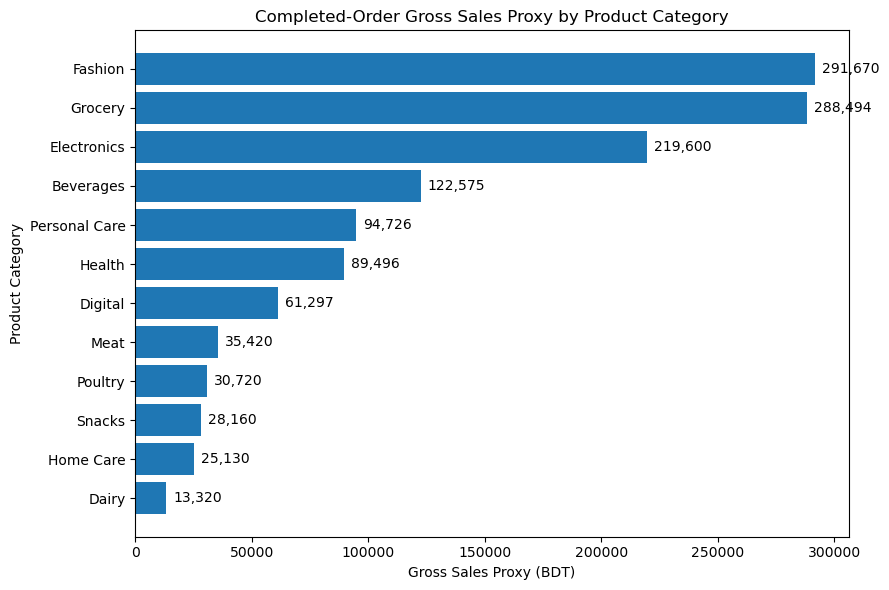

In [15]:
# Create the output folder if it does not already exist
os.makedirs("res_img", exist_ok=True)

# Load the exported SQL result
df = pd.read_csv("question 7.csv")

# Sort so the highest-revenue category appears at the top
plot_df = df.sort_values("total_revenue", ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(9, 6))

bars = plt.barh(
    plot_df["category"],
    plot_df["total_revenue"]
)

plt.title("Completed-Order Gross Sales Proxy by Product Category")
plt.xlabel("Gross Sales Proxy (BDT)")
plt.ylabel("Product Category")

# Add values beside the bars
for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 3000,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center"
    )

plt.tight_layout()

# Save the chart using the required naming convention
plt.savefig(
    "res_img/q7_category_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 8. Which individual products generate the highest revenue?

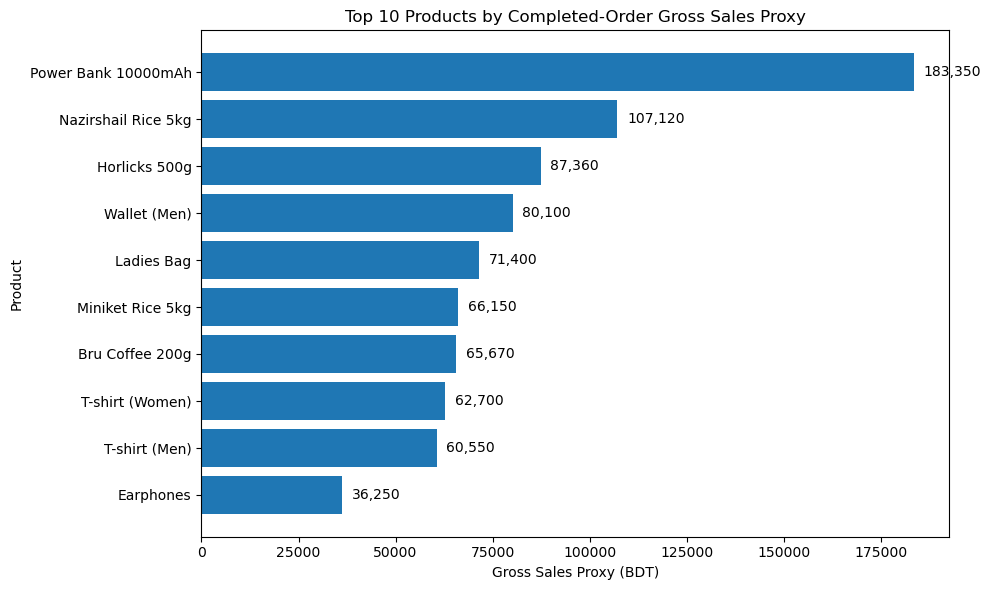

In [19]:
# Create output folder
os.makedirs("res_img", exist_ok=True)

# Load the exported SQL result
df = pd.read_csv("question 8.csv")

# Select the top 10 products by gross sales proxy
top_10 = (
    df.sort_values("total_revenue", ascending=False)
      .head(10)
      .sort_values("total_revenue", ascending=True)
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_10["product_name"],
    top_10["total_revenue"]
)

plt.title("Top 10 Products by Completed-Order Gross Sales Proxy")
plt.xlabel("Gross Sales Proxy (BDT)")
plt.ylabel("Product")

# Add values beside the bars
for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 2500,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center"
    )

plt.tight_layout()

# Save the chart
plt.savefig(
    "res_img/q8_top_products_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 9. What is the average order value (AOV) and Average Basket Size?

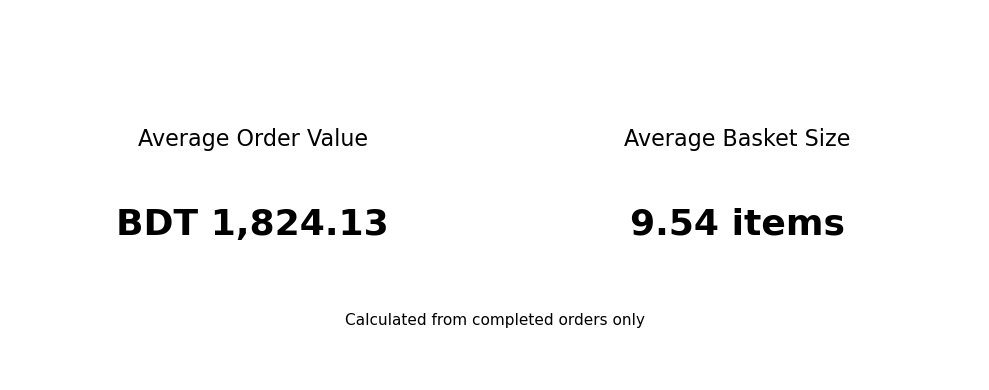

In [18]:
# Create output folder
os.makedirs("res_img", exist_ok=True)

# Load the exported SQL result
df = pd.read_csv("question 9.csv")

# Extract KPI values
avg_order_value = df["avg_order_value"].iloc[0]
avg_basket_size = df["avg_basket_size_items"].iloc[0]

# Create KPI-style visualization
plt.figure(figsize=(10, 4))
plt.axis("off")

# Average Order Value
plt.text(
    0.25,
    0.65,
    "Average Order Value",
    ha="center",
    va="center",
    fontsize=16
)

plt.text(
    0.25,
    0.42,
    f"BDT {avg_order_value:,.2f}",
    ha="center",
    va="center",
    fontsize=26,
    fontweight="bold"
)

# Average Basket Size
plt.text(
    0.75,
    0.65,
    "Average Basket Size",
    ha="center",
    va="center",
    fontsize=16
)

plt.text(
    0.75,
    0.42,
    f"{avg_basket_size:.2f} items",
    ha="center",
    va="center",
    fontsize=26,
    fontweight="bold"
)

plt.text(
    0.5,
    0.16,
    "Calculated from completed orders only",
    ha="center",
    va="center",
    fontsize=11
)

plt.tight_layout()

# Save the visualization
plt.savefig(
    "res_img/q9_aov_avg_basket_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 10. Which products are at risk of stock-out due to high sales volume and low inventory?

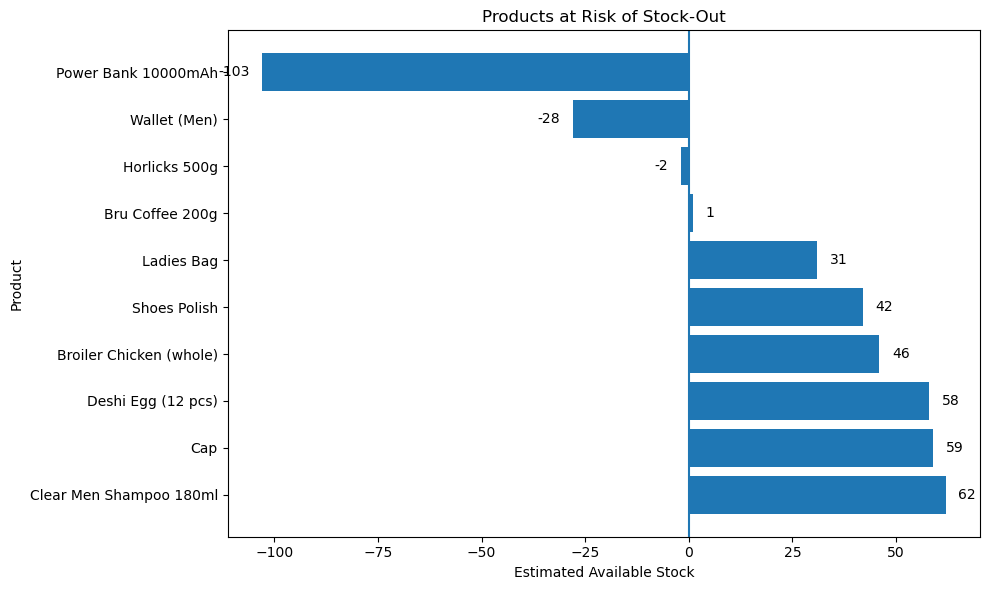

In [20]:
os.makedirs("res_img", exist_ok=True)

# Load the exported SQL result
df = pd.read_csv("question 10.csv")

# Select the 10 products with the lowest available stock
risk_df = (
    df.sort_values(
        ["available_stock", "total_sold"],
        ascending=[True, False]
    )
    .head(10)
    .sort_values("available_stock", ascending=False)
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    risk_df["product_name"],
    risk_df["available_stock"]
)

plt.axvline(0)

plt.title("Products at Risk of Stock-Out")
plt.xlabel("Estimated Available Stock")
plt.ylabel("Product")

# Add values beside the bars
for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 3 if value >= 0 else value - 3,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.tight_layout()

# Save the chart
plt.savefig(
    "res_img/q10_stockout_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 11. Which customers contribute the highest total revenue?

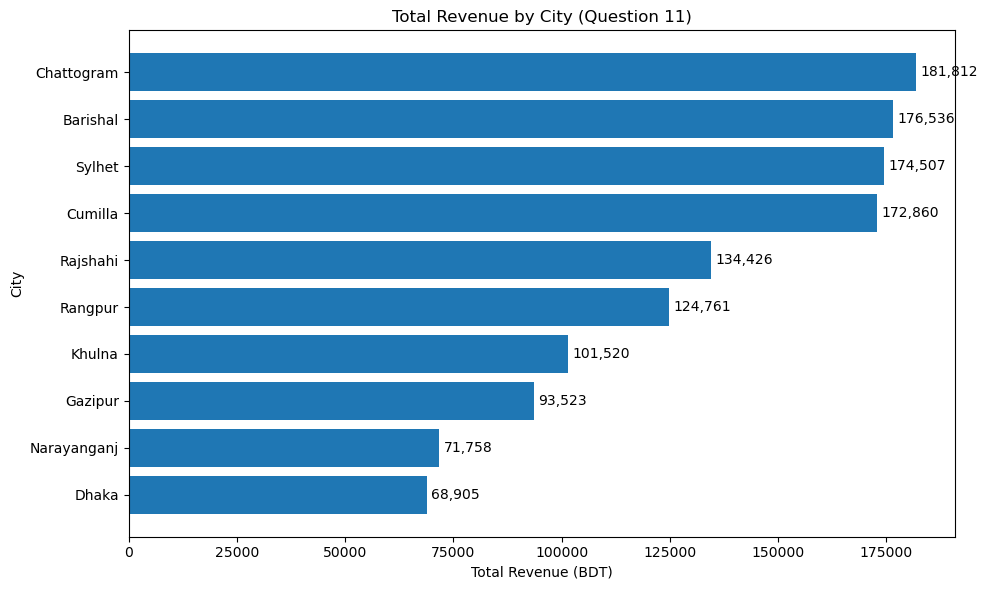

In [23]:
df = pd.read_csv("question 11.csv")

# Aggregate total revenue by city
city_revenue = df.groupby("city", as_index=False)["total_revenue"].sum()
city_revenue = city_revenue.sort_values("total_revenue", ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(10,6))
bars = plt.barh(city_revenue["city"], city_revenue["total_revenue"])

plt.title("Total Revenue by City (Question 11)")
plt.xlabel("Total Revenue (BDT)")
plt.ylabel("City")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1000, bar.get_y() + bar.get_height()/2, f"{width:,.0f}", va="center")

plt.tight_layout()
plt.savefig("res_img/q11_city_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

#### 12. Generate a list of cancellation rate by city; also the cancellation rate for customers.

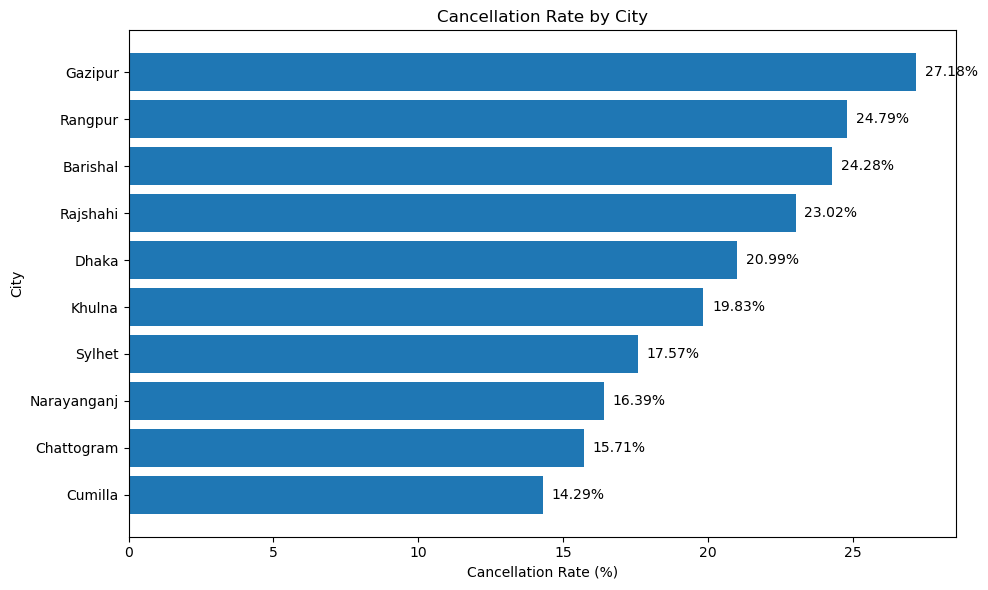

In [30]:
df = pd.read_csv("question 12.csv")

# Sort by cancellation rate
df = df.sort_values(by="cancellation_rate", ascending=True)

# Create output folder
os.makedirs("res_img", exist_ok=True)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(df["city"], df["cancellation_rate"])

plt.title("Cancellation Rate by City")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("City")

# Add value labels
for index, value in enumerate(df["cancellation_rate"]):
    plt.text(value + 0.3, index, f"{value:.2f}%", va="center")

plt.tight_layout()

# Save image
plt.savefig("res_img/qn12_cancellation_rate_by_city.png", dpi=300, bbox_inches="tight")


#### 13. Do male and female customers show different purchasing patterns by category?

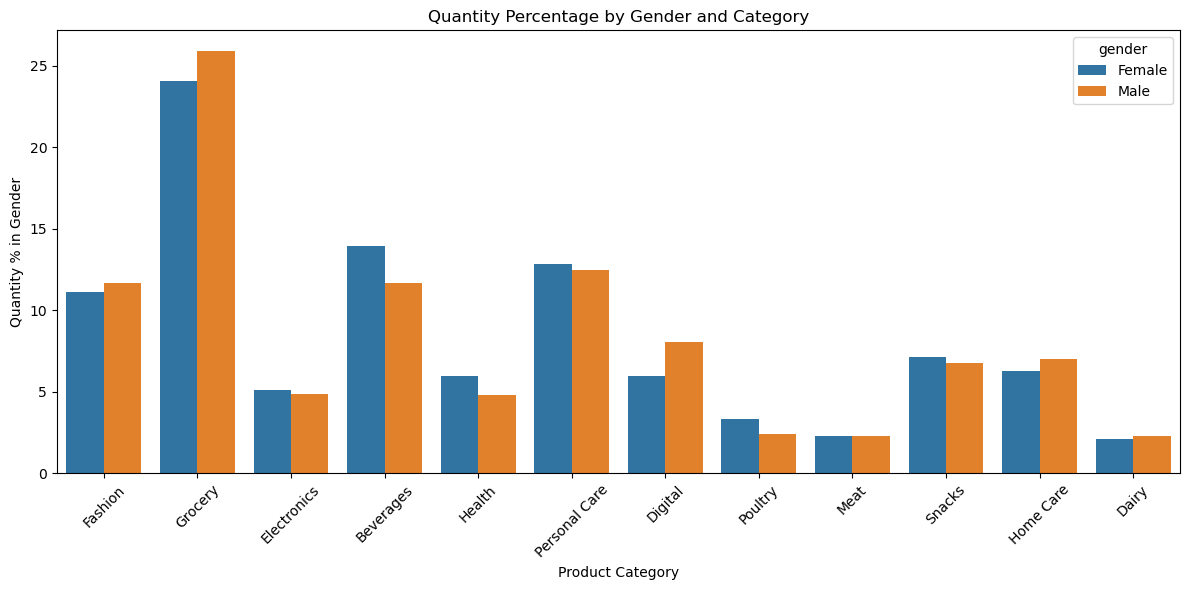

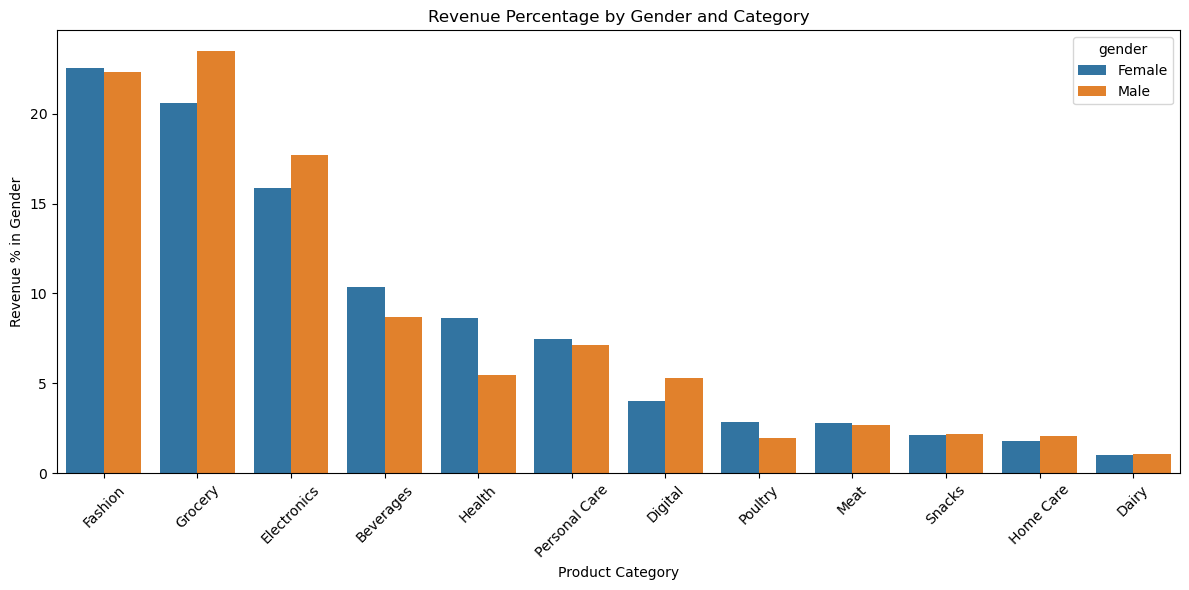

In [37]:
# Load data
df = pd.read_csv("question 13_detailed.csv")

# Create output folder
os.makedirs("res_img", exist_ok=True)

# Plot quantity and revenue percent by category and gender
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x="category",
    y="qty_percent_in_gender",
    hue="gender"
)
plt.title("Quantity Percentage by Gender and Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity % in Gender")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("res_img/qn13_gender_category_qty.png", dpi=300)
plt.show()

# Revenue percentage plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x="category",
    y="rev_percent_in_gender",
    hue="gender"
)
plt.title("Revenue Percentage by Gender and Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue % in Gender")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("res_img/qn13_gender_category_revenue.png", dpi=300)
plt.show()

#### 14. How does customer purchasing behavior change over time since account creation?

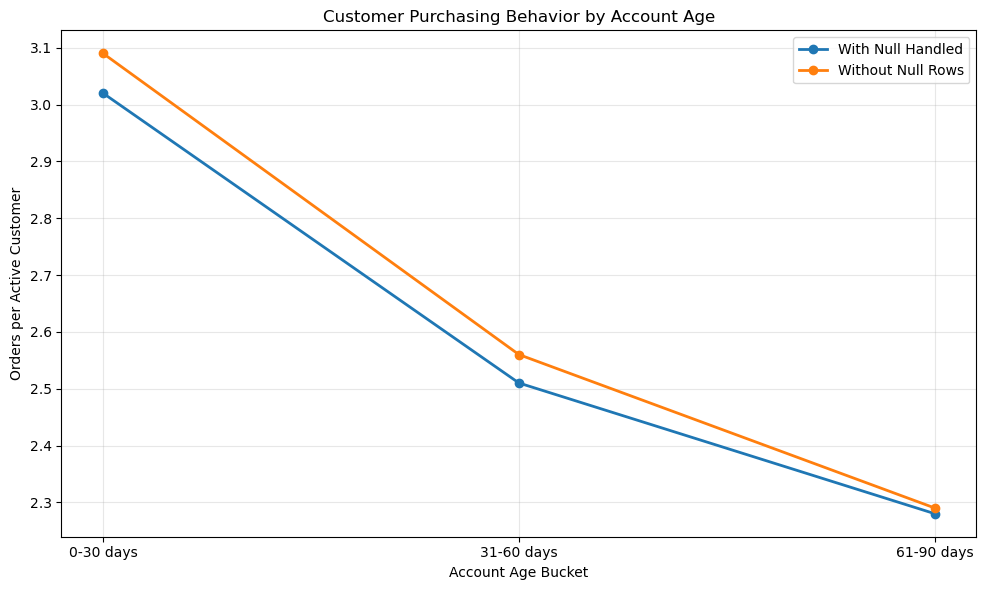

In [31]:
w_null = pd.read_csv("question 14_w_null.csv")
wo_null = pd.read_csv("question 14_wo_null.csv")

# Create output folder
os.makedirs("res_img", exist_ok=True)

# Create comparison chart
plt.figure(figsize=(10, 6))

plt.plot(
    w_null["account_age_bucket"],
    w_null["orders_per_active_customer"],
    marker="o",
    linewidth=2,
    label="With Null Handled"
)

plt.plot(
    wo_null["account_age_bucket"],
    wo_null["orders_per_active_customer"],
    marker="o",
    linewidth=2,
    label="Without Null Rows"
)

plt.title("Customer Purchasing Behavior by Account Age")
plt.xlabel("Account Age Bucket")
plt.ylabel("Orders per Active Customer")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save image
plt.savefig("res_img/qn14_customer_behavior_account_age.png", dpi=300, bbox_inches="tight")

plt.show()

#### 15. Generate a list of customers who ordered in October but didn’t order in December.

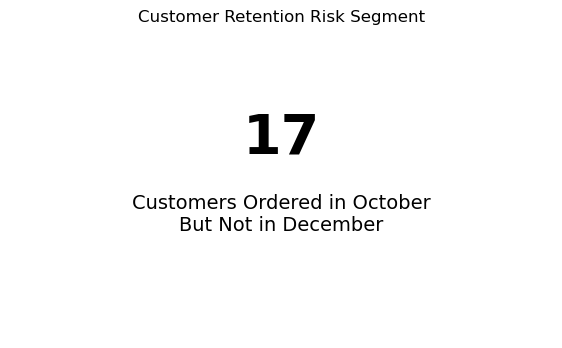

In [32]:
df = pd.read_csv("question 15.csv")

# Create output folder
os.makedirs("res_img", exist_ok=True)

# KPI Chart
plt.figure(figsize=(7, 4))
plt.axis('off')

plt.text(
    0.5,
    0.6,
    str(len(df)),
    fontsize=40,
    ha='center',
    fontweight='bold'
)

plt.text(
    0.5,
    0.35,
    "Customers Ordered in October\nBut Not in December",
    fontsize=14,
    ha='center'
)

plt.title("Customer Retention Risk Segment")

plt.savefig(
    "res_img/qn15_october_not_december_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 16. Generate a list of customers who ordered both in October & December.

#### 17. Which payment methods are used most frequently?

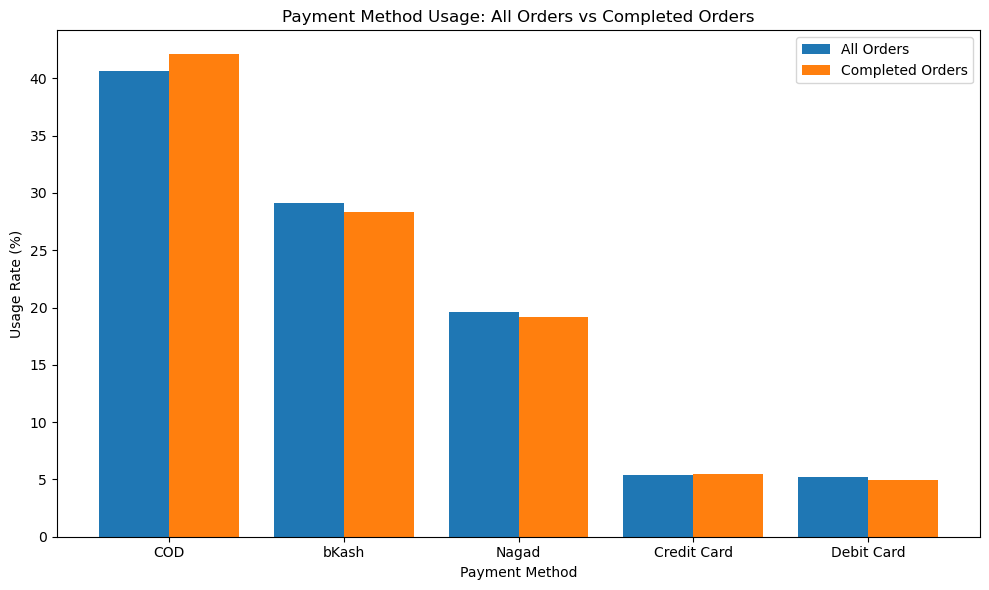

In [39]:
all_orders = pd.read_csv("question 17.csv")
completed_orders = pd.read_csv("question 17_completed_orders.csv")

# Rename columns for consistency
all_orders = all_orders.rename(columns={"pay_method": "method"})
completed_orders = completed_orders.rename(columns={"method": "method"})

# Create output folder
os.makedirs("res_img", exist_ok=True)

# Merge both datasets for comparison
comparison = all_orders[["method", "rate_of_usage"]].merge(
    completed_orders[["method", "rate_of_usage"]],
    on="method",
    suffixes=("_all_orders", "_completed_orders")
)

# Create grouped bar chart
x = range(len(comparison))

plt.figure(figsize=(10, 6))

plt.bar(
    [i - 0.2 for i in x],
    comparison["rate_of_usage_all_orders"],
    width=0.4,
    label="All Orders"
)

plt.bar(
    [i + 0.2 for i in x],
    comparison["rate_of_usage_completed_orders"],
    width=0.4,
    label="Completed Orders"
)

plt.xticks(x, comparison["method"])
plt.title("Payment Method Usage: All Orders vs Completed Orders")
plt.xlabel("Payment Method")
plt.ylabel("Usage Rate (%)")
plt.legend()

plt.tight_layout()

# Save image
plt.savefig("res_img/qn17_payment_method_usage.png", dpi=300, bbox_inches="tight")

plt.show()

#### 18. Is there any relationship between payment method and order status?

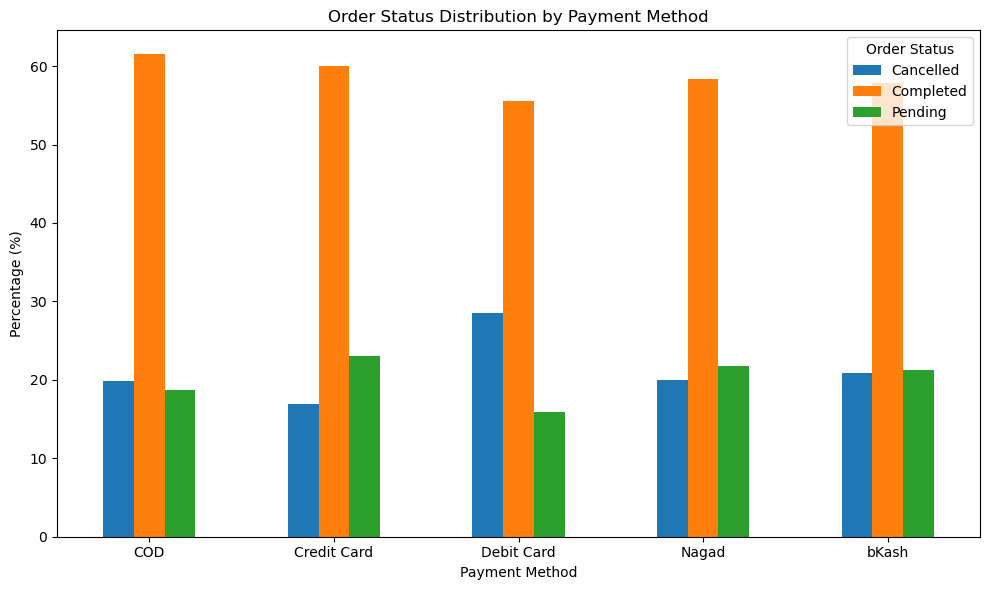

In [40]:
# Load data
df = pd.read_csv("question 18.csv")

# Create output folder
os.makedirs("res_img", exist_ok=True)

# Pivot data
pivot_df = df.pivot(
    index="pay_method",
    columns="order_status",
    values="rate_of_status"
)

# Plot
pivot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Order Status Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.legend(title="Order Status")
plt.xticks(rotation=0)

plt.tight_layout()

# Save figure
plt.savefig(
    "res_img/qn18_payment_method_order_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 19. Do certain cities prefer specific payment methods?

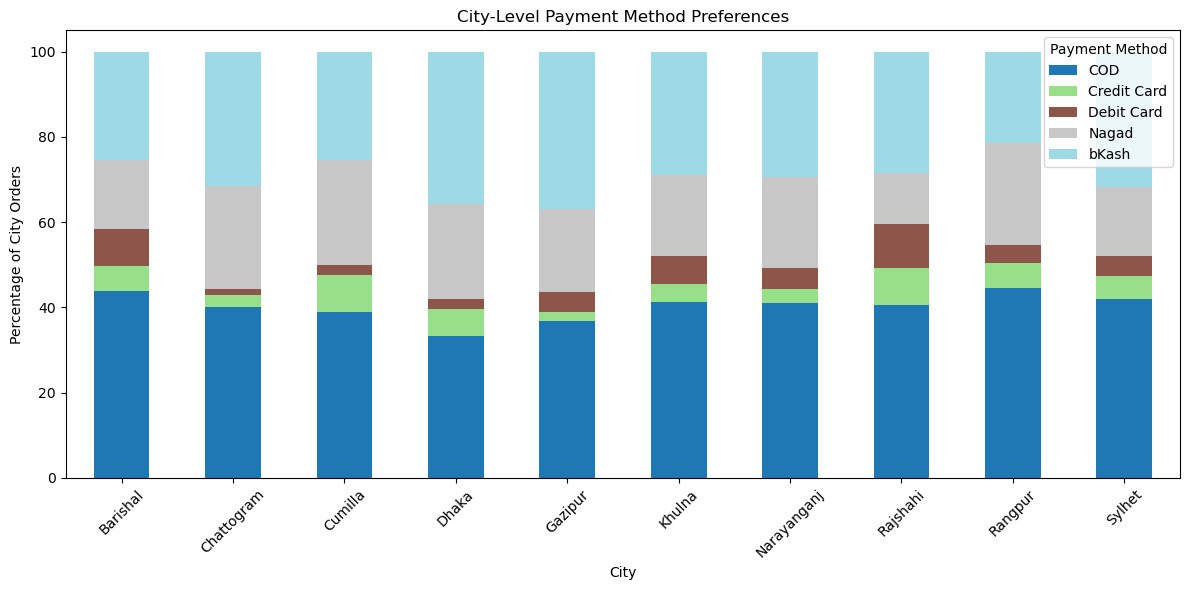

In [41]:
# Load data
df = pd.read_csv("question 19.csv")

# Ensure output folder exists
os.makedirs("res_img", exist_ok=True)

# Pivot for plotting
pivot_df = df.pivot(index="city", columns="pay_method", values="city_method_percentage")

# Plot stacked bar chart
pivot_df.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")

plt.title("City-Level Payment Method Preferences")
plt.xlabel("City")
plt.ylabel("Percentage of City Orders")
plt.xticks(rotation=45)
plt.legend(title="Payment Method")
plt.tight_layout()

# Save figure
plt.savefig("res_img/qn19_city_payment_preferences.png", dpi=300, bbox_inches="tight")
plt.show()

#### 20. Are higher-value orders associated with specific payment methods?

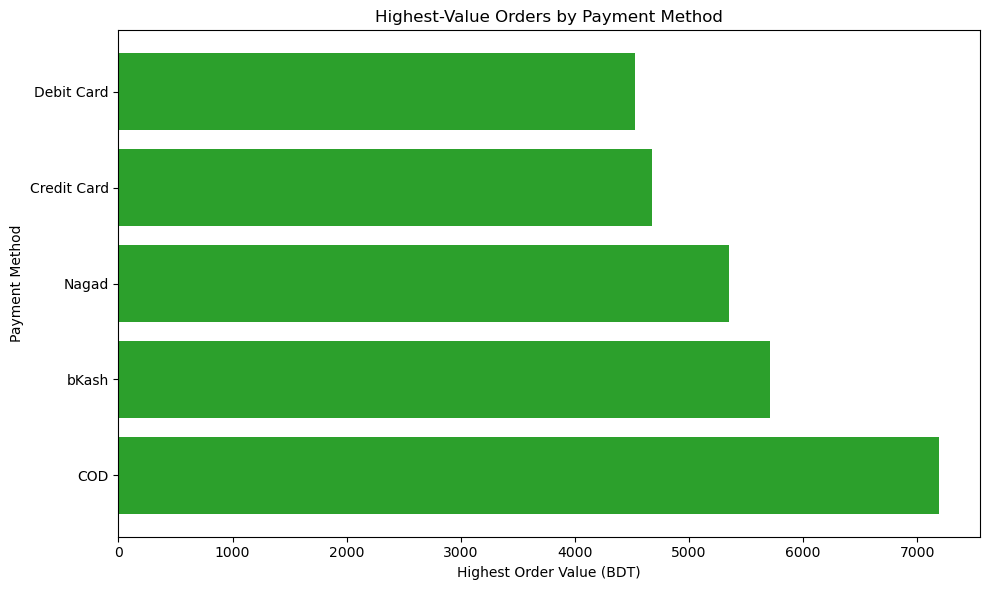

In [42]:
df = pd.read_csv("question 20.csv")

# Ensure output folder exists
os.makedirs("res_img", exist_ok=True)

# Sort by highest_order_value descending
df = df.sort_values("highest_order_value", ascending=False)

# Plot horizontal bar for highest order value per payment method
plt.figure(figsize=(10,6))
plt.barh(df["pay_method"], df["highest_order_value"], color="tab:green")
plt.xlabel("Highest Order Value (BDT)")
plt.ylabel("Payment Method")
plt.title("Highest-Value Orders by Payment Method")
plt.tight_layout()

# Save figure
plt.savefig("res_img/qn20_high_value_orders.png", dpi=300, bbox_inches="tight")
plt.show()

#### 21. What is the average number of items per order by payment method?

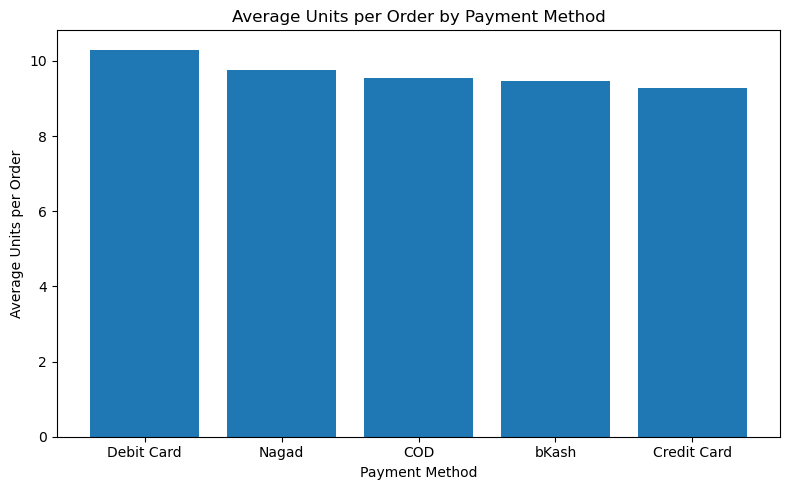

In [45]:
# Load data
df = pd.read_csv("question 21.csv")

# Create output folder
os.makedirs("res_img", exist_ok=True)

# Sort by avg_units_per_order
df = df.sort_values("avg_unit_per_order", ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.bar(df["pay_method"], df["avg_unit_per_order"], color="tab:blue")

plt.title("Average Units per Order by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Units per Order")
plt.tight_layout()

# Save figure
plt.savefig("res_img/qn21_avg_units_per_order.png", dpi=300, bbox_inches="tight")
plt.show()

#### 22. Create a list to show the difference between the category average price and product’s price for all the products.

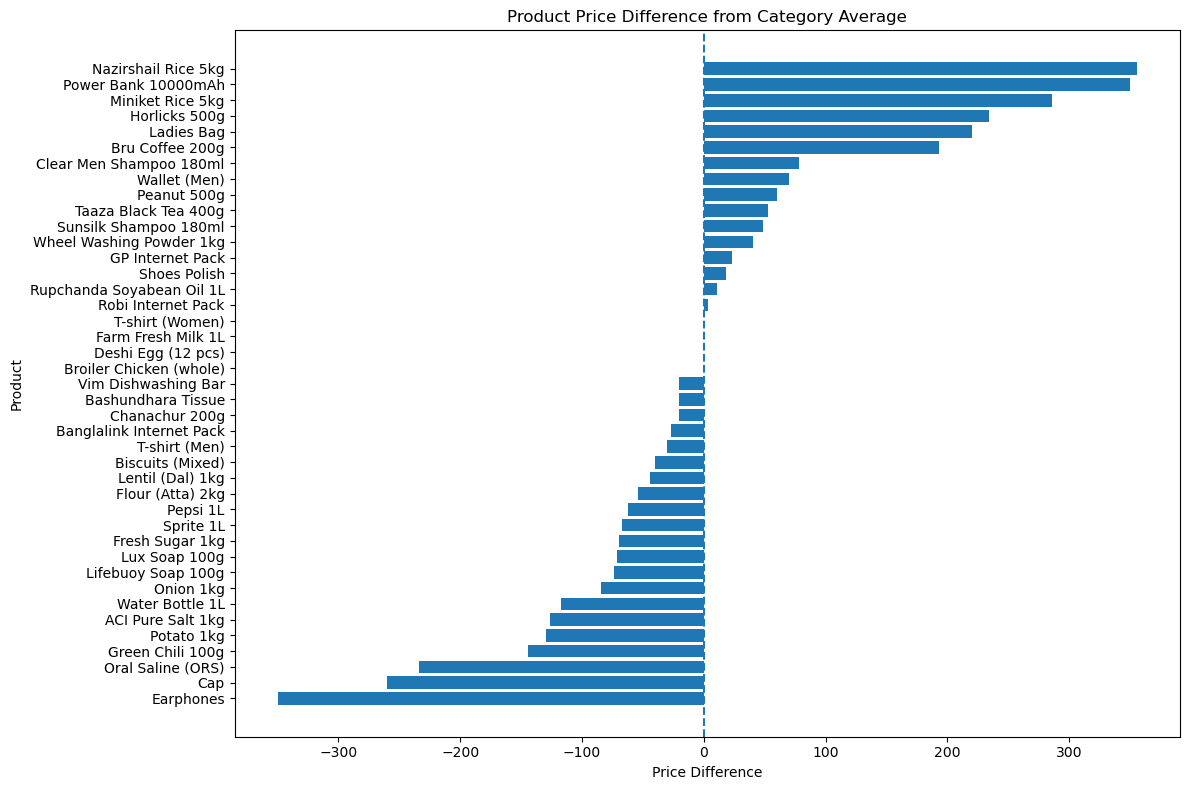

In [38]:
# Load data
df = pd.read_csv("question 22.csv")

# Sort by absolute difference
df = df.sort_values("price_diff")

# Create output folder
os.makedirs("res_img", exist_ok=True)

# Create chart
plt.figure(figsize=(12, 8))

plt.barh(
    df["product_name"],
    df["price_diff"]
)

plt.axvline(x=0, linestyle="--")

plt.title("Product Price Difference from Category Average")
plt.xlabel("Price Difference")
plt.ylabel("Product")

plt.tight_layout()

# Save figure
plt.savefig(
    "res_img/qn22_product_price_difference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 23. Which product pairs are most frequently purchased together in the same order?

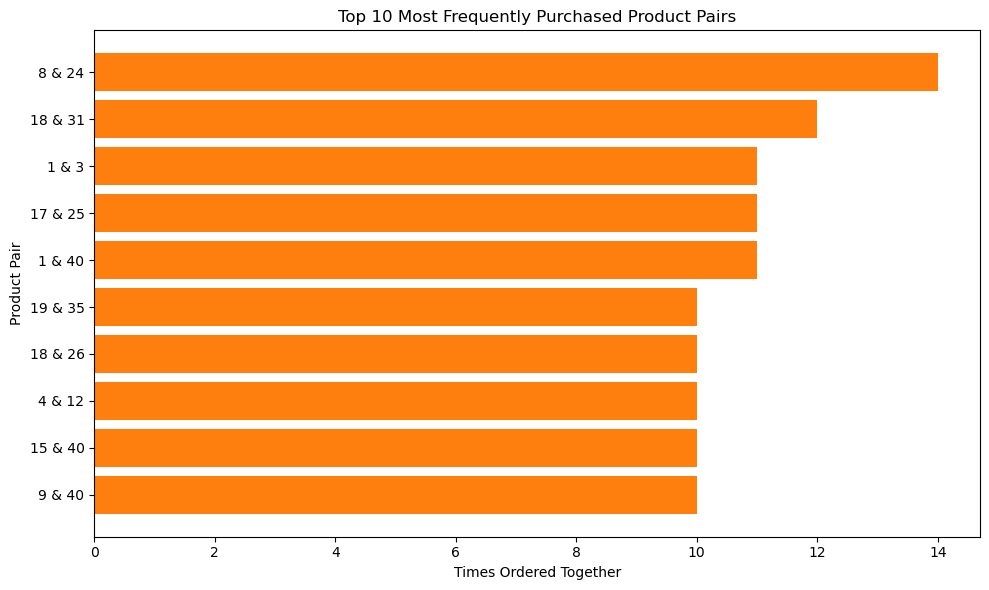

In [46]:
# Load data
df = pd.read_csv("question 23_Competed_orders.csv")

# Aggregate top 10 pairs
top_pairs = df.sort_values("times_ordered_together", ascending=False).head(10)
top_pairs["pair_label"] = top_pairs["product_id_1"].astype(str) + " & " + top_pairs["product_id_2"].astype(str)

# Create output folder
os.makedirs("res_img", exist_ok=True)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_pairs["pair_label"], top_pairs["times_ordered_together"], color="tab:orange")
plt.xlabel("Times Ordered Together")
plt.ylabel("Product Pair")
plt.title("Top 10 Most Frequently Purchased Product Pairs")
plt.gca().invert_yaxis()
plt.tight_layout()

# Save figure
plt.savefig("res_img/qn23_top_product_pairs.png", dpi=300, bbox_inches="tight")
plt.show()

#### 24. Which product pairs generate the highest total revenue when sold together?

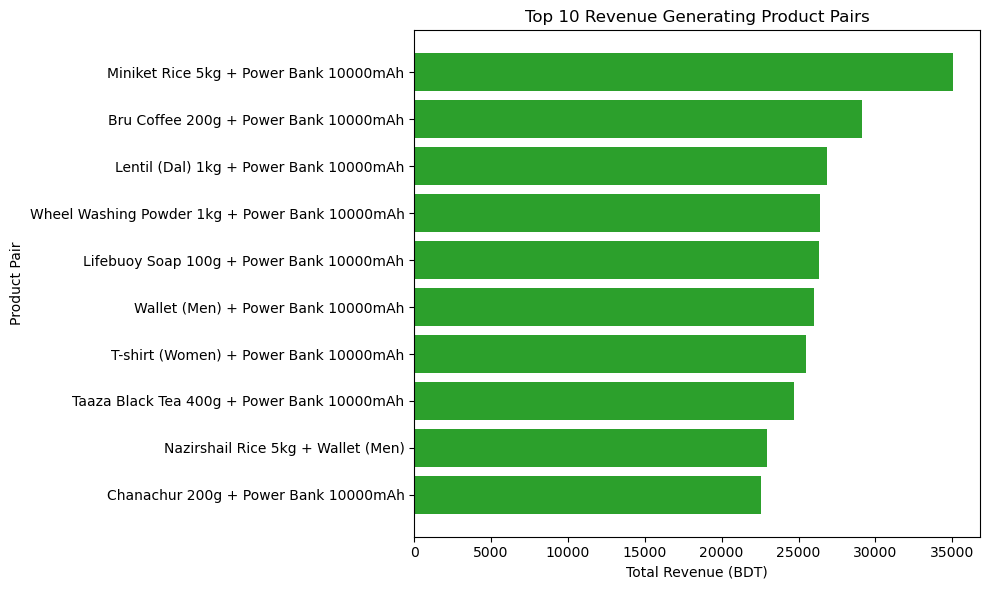

In [47]:
# Load data (IMPORTANT: correct file name usage)
df = pd.read_csv("question 24.csv")

# Sort by revenue
top_pairs = df.sort_values("total_revenue", ascending=False).head(10)

# Create pair label
top_pairs["pair"] = top_pairs["product_1"] + " + " + top_pairs["product_2"]

# Ensure folder exists
os.makedirs("res_img", exist_ok=True)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_pairs["pair"], top_pairs["total_revenue"], color="tab:green")

plt.xlabel("Total Revenue (BDT)")
plt.ylabel("Product Pair")
plt.title("Top 10 Revenue Generating Product Pairs")
plt.gca().invert_yaxis()

plt.tight_layout()

# Save figure
plt.savefig("res_img/qn24_top_revenue_pairs.png", dpi=300, bbox_inches="tight")
plt.show()

#### 25. Generate a daily report containing the columns Date, Total Orders, Total Items, Completed Orders, Cancelled Orders, Total Revenue

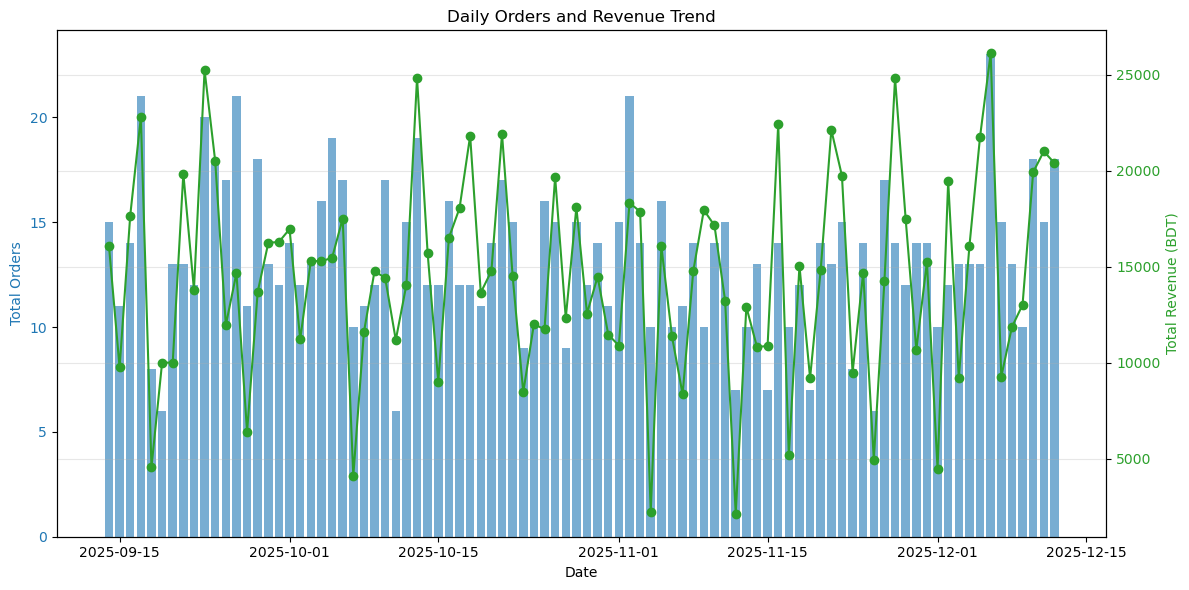

In [28]:
# Load daily report data
df = pd.read_csv("question 25.csv")

# Ensure the directory exists
os.makedirs("res_img", exist_ok=True)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Plot daily orders and revenue
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar for total orders
ax1.bar(df['date'], df['total_orders'], color='tab:blue', alpha=0.6, label='Total Orders')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Orders', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Line for revenue
ax2 = ax1.twinx()
ax2.plot(df['date'], df['total_revenue'], color='tab:green', marker='o', label='Total Revenue')
ax2.set_ylabel('Total Revenue (BDT)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

plt.title('Daily Orders and Revenue Trend')
fig.tight_layout()
plt.grid(alpha=0.3)

# Save the figure
plt.savefig("res_img/qn25_daily_report.png", dpi=300, bbox_inches="tight")
plt.show()